In [8]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from pydantic import BaseModel
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [6]:
model = ChatGroq(model="openai/gpt-oss-20b")

In [15]:
class LLMState(BaseModel):

    question: str
    answer: str

In [ ]:
def llm_qa(llm: LLMState) -> LLMState:

    question = llm.question
    prompt = f'Answer the following question {question}'
    response = model.invoke(prompt)
    llm.answer = response.content # content use korar karon plain str nite jeno pari
    return llm


In [21]:
graph = StateGraph(LLMState)

graph.add_node('llm_qa', llm_qa)

graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow = graph.compile()


In [ ]:
initial_state = {
    "question": "Who is the creator of Python?",
    "answer": ""
}

final_state = workflow.invoke(initial_state)
print(final_state["answer"]) # ["answer"] use korar karon final__state dictonay return korbe

The creator of Python is **Guido van Rossum**.


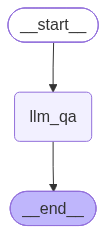

In [24]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())